MULTINOMIAL LOGISTIC REGRESSION PROJECT

Dataset loaded successfully!

Dataset Shape:
(50000, 21)

First 5 Rows:
   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN   

   

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model trained successfully!

MODEL PERFORMANCE
Accuracy: 0.24

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          CS       0.24      0.99      0.39      2409
       Civil       0.00      0.00      0.00      1009
         ECE       0.00      0.00      0.00      1793
          EE       0.00      0.00      0.00      1395
          IT       0.21      0.01      0.02      1989
  Mechanical       0.00      0.00      0.00      1405

    accuracy                           0.24     10000
   macro avg       0.07      0.17      0.07     10000
weighted avg       0.10      0.24      0.10     10000


CONFUSION MATRIX
[[2379    0    0    0   30    0]
 [ 998    0    0    0   11    0]
 [1778    0    0    0   15    0]
 [1381    0    0    0   14    0]
 [1968    0    0    0   21    0]
 [1394    0    0    0   11    0]]


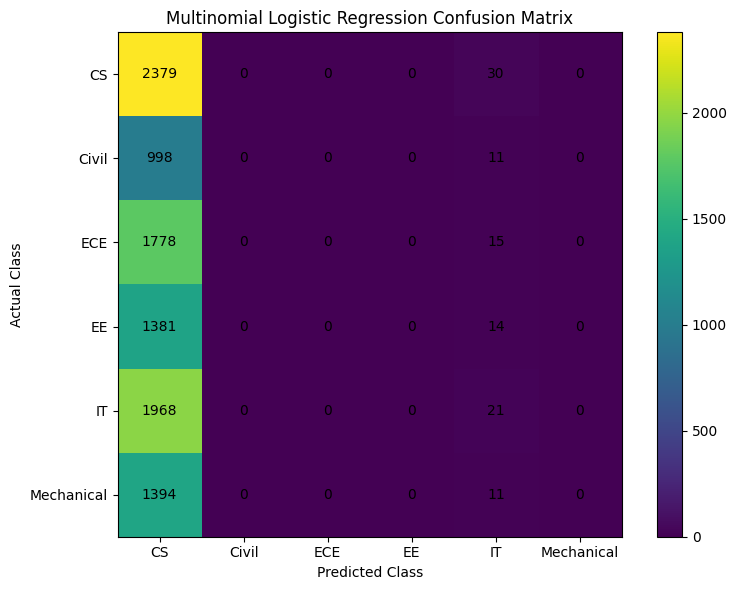


FINAL CONCLUSION

The Placement dataset was used to build a
Multinomial Logistic Regression model.

The target variable was Stream, containing
multiple classes such as:

CS, IT, ECE, Mechanical, EE and Civil.

The pipeline performed:

1. Missing Value Imputation
2. Feature Scaling
3. Categorical Feature Encoding
4. Multinomial Logistic Regression

The model was evaluated using:

1. Accuracy
2. Classification Report
3. Confusion Matrix

FINAL RESULT

Accuracy: 0.2400



In [1]:
# ============================================================
# MULTINOMIAL LOGISTIC REGRESSION PROJECT
# Dataset: placement_predict_50k_adjusted(1).csv
# Target: Stream
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

DATA_PATH = "placement_predict_50k_adjusted.csv"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("MULTINOMIAL LOGISTIC REGRESSION PROJECT")
print("=" * 60)

print("\nDataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

# Stream is the multi-class target

X = df.drop(
    columns=[
        "Stream",
        "IsAnomaly"
    ],
    errors="ignore"
)

y = df["Stream"]

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Classes:")
print(y.unique())


# ------------------------------------------------------------
# 5. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ------------------------------------------------------------

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("\nNumerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))


# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 7. CREATE PREPROCESSING PIPELINE
# ------------------------------------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 8. CREATE MULTINOMIAL LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "multinomial_logistic_regression",
            LogisticRegression(
                max_iter=2000,
                solver="lbfgs",
                multi_class="multinomial",
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("\nMultinomial Logistic Regression Model Created!")


# ------------------------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING MULTINOMIAL LOGISTIC REGRESSION")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")


# ------------------------------------------------------------
# 10. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 11. MODEL EVALUATION
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print("Accuracy:", round(accuracy, 4))


# ------------------------------------------------------------
# 12. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 13. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


# ------------------------------------------------------------
# 14. VISUALIZE CONFUSION MATRIX
# ------------------------------------------------------------

classes = model.named_steps[
    "multinomial_logistic_regression"
].classes_

plt.figure(figsize=(8, 6))

plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(len(classes)),
    classes
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Multinomial Logistic Regression Confusion Matrix"
)

for i in range(len(cm)):
    for j in range(len(cm[0])):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print(f"""
The Placement dataset was used to build a
Multinomial Logistic Regression model.

The target variable was Stream, containing
multiple classes such as:

CS, IT, ECE, Mechanical, EE and Civil.

The pipeline performed:

1. Missing Value Imputation
2. Feature Scaling
3. Categorical Feature Encoding
4. Multinomial Logistic Regression

The model was evaluated using:

1. Accuracy
2. Classification Report
3. Confusion Matrix

FINAL RESULT

Accuracy: {accuracy:.4f}
""")

print("=" * 60)